### Importing libraries


In [8]:
import numpy as np  
import pandas as pd
import pymoo
import matplotlib.pyplot as plt
from pymoo.problems import get_problem 
from pymoo.optimize import minimize
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.util.plotting import plot
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.visualization.scatter import Scatter 

###  Define problem

In [9]:
problem = get_problem("dtlz4", n_var=3, n_obj=3) # Get 3-obj DTlz4 problem with 3 variables 

###  Configure algorithm

In [10]:
algorithm = NSGA2(pop_size=300) # NSGA-II with population size 150

### Generate Pareto Optimal Solutions

In [11]:
# Optimize
res = minimize(problem, 
               algorithm,
               ('n_gen', 300), # Evolve for 100 generations
               seed=1,
               verbose=False)

X = res.X # Input variables
F = res.F # Objective values  

### Process result


In [12]:
n_var = problem.n_var # Number of variables 
n_obj = problem.n_obj # Number of objectives
var_cols = [f'x{i}' for i in range(1, n_var+1)] 
obj_cols = [f'f{i}' for i in range(1, n_obj+1)]  

df = pd.DataFrame(X, columns=var_cols) 
for i in range(n_obj):
    df[obj_cols[i]] = F[:, i] # Objective values to DataFrame

### Generating pareto front

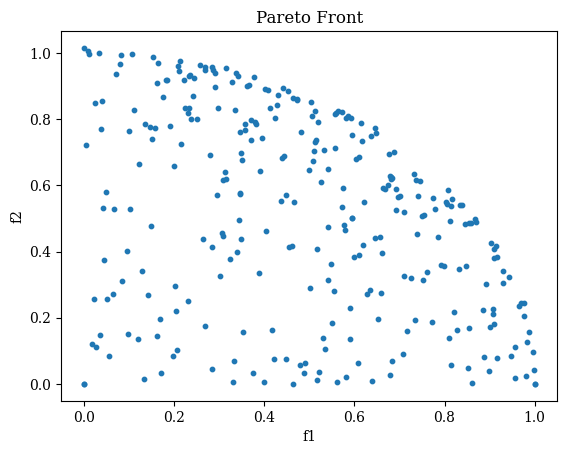

In [13]:
# Get Pareto front 
front = res.F  

# Plot
plt.scatter(front[:,0], front[:,1], s=10) 
plt.title("Pareto Front")
plt.xlabel("f1")
plt.ylabel("f2")
plt.show()

# 3D Visualization for 3 Objection Functions

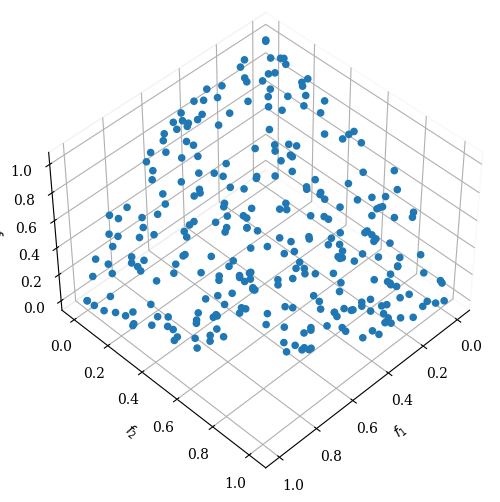

In [14]:
Scatter(angle=(45,45)).add(front).show()

# Radial Charts for 4 Objective Function Visualization

Text(0.5, 1.0, 'Pareto Front')

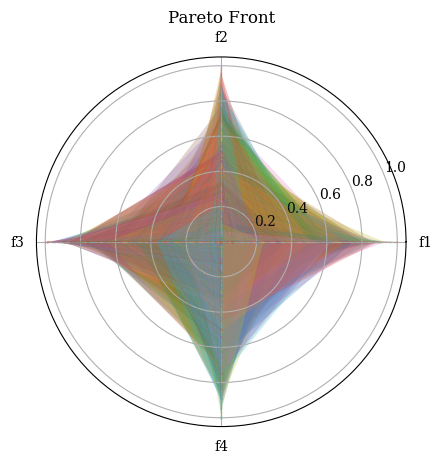

In [39]:
import numpy as np

fig, ax = plt.subplots(subplot_kw=dict(polar=True))

objectives = ["f1", "f2", "f3", "f4"]  
num_objs = len(objectives)

theta = np.linspace(0, 2 * np.pi, num_objs, endpoint=False)

for i, soln in enumerate(res.F):
    values = soln   

    ax.plot(theta, values, 'o-', markersize=0.1, linewidth=0.05)
  
    ax.fill(theta, values, alpha=0.25)

ax.set_thetagrids(theta * 180/np.pi, objectives)
plt.title("Pareto Front")

#plt.savefig('4O-2V.png')